<a href="https://colab.research.google.com/github/EfrainHernandezCortes/Procesos-Estocasticos/blob/main/Descomposici%C3%B3n_Can%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Descomposición Canónica

In [23]:
import sympy as sp
import networkx as nx
import graphviz
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve

**1.** Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.

Tenemos las matriz P:

In [3]:
P = sp.Matrix([[1/4, 0, 0, 0, 0, 0, 3/4],
               [1/8, 1/8, 1/4, 0, 1/4, 1/8, 1/8],
               [0, 0, 2/5, 1/5, 2/5, 0, 0],
               [0, 0, 1/2, 1/2, 0, 0, 0],
               [0, 0, 0, 1/2, 1/2, 0, 0],
               [0, 1/5, 0, 1/5, 1/5, 1/5, 1/5],
               [4/5, 0, 0, 0, 0, 0, 1/5]])
P

Matrix([
[ 0.25,     0,    0,   0,    0,     0,  0.75],
[0.125, 0.125, 0.25,   0, 0.25, 0.125, 0.125],
[    0,     0,  0.4, 0.2,  0.4,     0,     0],
[    0,     0,  0.5, 0.5,    0,     0,     0],
[    0,     0,    0, 0.5,  0.5,     0,     0],
[    0,   0.2,    0, 0.2,  0.2,   0.2,   0.2],
[  0.8,     0,    0,   0,    0,     0,   0.2]])

Con estados: $\{a, b, c, d, e, f, g\}$

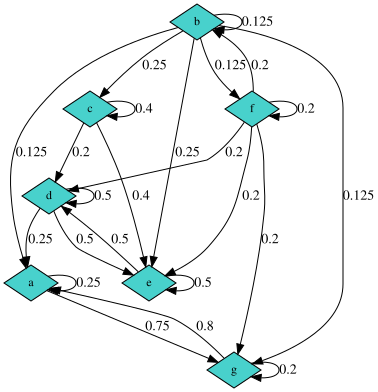

In [4]:
dot = graphviz.Digraph()
#dot.attr(rankdir='LR')
dot.attr('node', shape='diamond', style='filled',
         fillcolor='mediumturquoise', fontsize='12')
dot.node('E1', 'a')
dot.node('E2', 'b')
dot.node('E3', 'c')
dot.node('E4', 'd')
dot.node('E5', 'e')
dot.node('E6', 'f')
dot.node('E7', 'g')
transiciones = [
    ('E1','E1','0.25'),
    ('E1','E7','0.75'),
    ('E2','E1','0.125'),
    ('E2','E2','0.125'),
    ('E2','E3','0.25'),
    ('E2','E5','0.25'),
    ('E2','E6','0.125'),
    ('E2','E7','0.125'),
    ('E3','E3','0.4'),
    ('E3','E4','0.2'),
    ('E3','E5','0.4'),
    ('E4','E1','0.25'),
    ('E4','E4','0.5'),
    ('E4','E5','0.5'),
    ('E5','E4','0.5'),
    ('E5','E5','0.5'),
    ('E6','E2','0.2'),
    ('E6','E4','0.2'),
    ('E6','E5','0.2'),
    ('E6','E6','0.2'),
    ('E6','E7','0.2'),
    ('E7','E1','0.8'),
    ('E7','E7','0.2'),
]
for origen, destino, prob in transiciones:
    if prob != '0':
        dot.edge(origen, destino, label=prob)
dot

**2.** Determine si la matriz tiene o no distribución límite.


Primero determinamos si la matriz es regular.

In [9]:
P2 = P**2
P3 = P**3
print(P2)
print(P3)

Matrix([[0.662500000000000, 0, 0, 0, 0, 0, 0.337500000000000], [0.146875000000000, 0.0406250000000000, 0.131250000000000, 0.200000000000000, 0.281250000000000, 0.0406250000000000, 0.159375000000000], [0, 0, 0.260000000000000, 0.380000000000000, 0.360000000000000, 0, 0], [0, 0, 0.450000000000000, 0.350000000000000, 0.200000000000000, 0, 0], [0, 0, 0.250000000000000, 0.500000000000000, 0.250000000000000, 0, 0], [0.185000000000000, 0.0650000000000000, 0.150000000000000, 0.240000000000000, 0.190000000000000, 0.0650000000000000, 0.105000000000000], [0.360000000000000, 0, 0, 0, 0, 0, 0.640000000000000]])
Matrix([[0.435625000000000, 0, 0, 0, 0, 0, 0.564375000000000], [0.169296875000000, 0.0132031250000000, 0.162656250000000, 0.275000000000000, 0.211406250000000, 0.0132031250000000, 0.155234375000000], [0, 0, 0.294000000000000, 0.422000000000000, 0.284000000000000, 0, 0], [0, 0, 0.355000000000000, 0.365000000000000, 0.280000000000000, 0, 0], [0, 0, 0.350000000000000, 0.425000000000000, 0.22500

Podemos ver que dos potencias consecutivas de la matriz $P$ son no positivas, por lo tanto la matriz no es regular. Lo que indica que la matriz **no** tiene distribución límite.

**3.** Escriba la descomposición canónica de la matriz, determine el límite de la potencia $n$-ésima y compare contra las distribuciones límite de las submatrices.

Se tienen las clases:

$\{b, f\}$, transitoria,

$\{a, g\}$, recurrente,

$\{c, d, e\}$, recurrente.

La CM es irreducible, no ergódica, no regular, estocástica.

Descomposición Canónica de la matriz:

In [10]:
Pr = sp.Matrix([[1/8, 1/8, 1/8, 1/8, 1/4, 0, 1/4],
                [1/5, 1/5, 0, 1/5, 0, 1/5, 1/5],
                [0, 0, 1/4, 3/4, 0, 0, 0],
                [0, 0, 4/5, 1/5, 0, 0, 0],
                [0, 0, 0, 0, 2/5, 1/5, 2/5],
                [0, 0, 0, 0, 1/2, 1/2, 0],
                [0, 0, 0, 0, 0, 1/2, 1/2]])
Pr

Matrix([
[0.125, 0.125, 0.125, 0.125, 0.25,   0, 0.25],
[  0.2,   0.2,     0,   0.2,    0, 0.2,  0.2],
[    0,     0,  0.25,  0.75,    0,   0,    0],
[    0,     0,   0.8,   0.2,    0,   0,    0],
[    0,     0,     0,     0,  0.4, 0.2,  0.4],
[    0,     0,     0,     0,  0.5, 0.5,    0],
[    0,     0,     0,     0,    0, 0.5,  0.5]])

In [14]:
Pr2 = Pr**2
Pr3 = Pr**3
Pr4 = Pr**4
print(Pr2)
print(Pr3)
print(Pr4)

Matrix([[0.0406250000000000, 0.0406250000000000, 0.146875000000000, 0.159375000000000, 0.131250000000000, 0.200000000000000, 0.281250000000000], [0.0650000000000000, 0.0650000000000000, 0.185000000000000, 0.105000000000000, 0.150000000000000, 0.240000000000000, 0.190000000000000], [0, 0, 0.662500000000000, 0.337500000000000, 0, 0, 0], [0, 0, 0.360000000000000, 0.640000000000000, 0, 0, 0], [0, 0, 0, 0, 0.260000000000000, 0.380000000000000, 0.360000000000000], [0, 0, 0, 0, 0.450000000000000, 0.350000000000000, 0.200000000000000], [0, 0, 0, 0, 0.250000000000000, 0.500000000000000, 0.250000000000000]])
Matrix([[0.0132031250000000, 0.0132031250000000, 0.169296875000000, 0.155234375000000, 0.162656250000000, 0.275000000000000, 0.211406250000000], [0.0211250000000000, 0.0211250000000000, 0.138375000000000, 0.180875000000000, 0.196250000000000, 0.258000000000000, 0.184250000000000], [0, 0, 0.435625000000000, 0.564375000000000, 0, 0, 0], [0, 0, 0.602000000000000, 0.398000000000000, 0, 0, 0], [0

Volvemos a notar que el límite de la matriz canónica no va a converger. Sin embargo, se puede obtener la distribución límite de las submatrices, según sus clases.

In [21]:
#Submatriz {b,f}, {b,f}
S1 = sp.Matrix([[1/8, 1/8],
                [1/5, 1/5]])
#Submatriz {b,f}, {a,g}
S2 = sp.Matrix([[1/8, 1/8],
                [0, 1/5]])
#Submatriz {b,f}, {c,d,e}
S3 = sp.Matrix([[1/4, 0, 1/4],
                [0, 1/5, 1/5]])
#Submatriz {a,g}, {b,f}
S4 = sp.Matrix([[0, 0],
                [0, 0]])
#Submatriz {a,g}, {a,g}
S5 = sp.Matrix([[1/4, 3/4],
                [4/5, 1/5]])
#Submatriz {a,g}, {c,d,e}
S6 = sp.Matrix([[0, 0, 0],
                [0, 0, 0]])
#Submatriz {c,d,e}, {b,f}
S7 = sp.Matrix([[0, 0],
                [0, 0],
                [0, 0]])
#Submatriz {c,d,e}, {a,g}
S8 = sp.Matrix([[0, 0],
                [0, 0],
                [0, 0]])
#Submatriz {c,d,e}, {c,d,e}
S9 = sp.Matrix([[2/5, 1/5, 2/5],
                [1/2, 1/2, 0],
                [0, 1/2, 1/2]])

Tenemos que las únicas submatrices regulares son las que se encuentran en la diagonal de la matriz canónica: $S1, S5, S9$, según la notación dada. Se obtendrá la distribución límite de cada una de estas matriz.
Para esto, se hará:

$\pi=P\pi$,

$∑x_i=1$

In [25]:
x, y, z = sp.symbols('x y z')
pi2 = sp.Matrix([x, y])
pi3 = sp.Matrix([x, y, z])

Para $S1$:



In [27]:
M1 = S1.T * pi2
I = sp.eye(2)
A = S1.T - I
eq1 = Eq(A[0,0]*x + A[0,1]*y, 0)
eq_norm = Eq(x + y, 1)

sol = solve((eq1, eq_norm), (x, y))
print("La distribución límite de la submatriz S1 es: ", sol)

La distribución límite de la submatriz S1 es:  {x: 0.186046511627907, y: 0.813953488372093}


Para $S5$:

In [29]:
M5 = S5.T * pi2
I = sp.eye(2)
A = S5.T - I
eq1 = Eq(A[0,0]*x + A[0,1]*y, 0)
eq_norm = Eq(x + y, 1)

sol = solve((eq1, eq_norm), (x, y))
print("La distribución límite de la submatriz S5 es: ", sol)

La distribución límite de la submatriz S5 es:  {x: 0.516129032258065, y: 0.483870967741935}


Para $S9$:

In [30]:
M9 = S9.T * pi3
I = sp.eye(3)
A = S9.T - I
eq1 = Eq(A[0,0]*x + A[0,1]*y + A[0,2]*z, 0)
eq2 = Eq(A[1,0]*x + A[1,1]*y + A[1,2]*z, 0)
eq_norm = Eq(x + y + z, 1)

sol = solve((eq1, eq2, eq_norm), (x, y, z))
print("La distribución límite de la submatriz S9 es: ", sol)

La distribución límite de la submatriz S9 es:  {x: 0.333333333333333, y: 0.400000000000000, z: 0.266666666666667}


**4.** Escriba un programa que encuentre la descomposición canónica de una matriz dada.

In [31]:
#Se crea la función para obtener la forma canónica de la matriz dada.
def forma_canonica(P, Estados):
    n = P.rows
    adj = {i: [] for i in range(n)}
    for i in range(n):
        for j in range(n):
            if P[i, j] > 0:
                adj[i].append(j)

    #Se crea la función para obtener las clases de la CM.
    def obtener_clases(n, adj):
        visitados = [False] * n
        clases = []
        for i in range(n):
            if not visitados[i]:
                alcanzables_desde_i = set()
                stack = [i]
                while stack:
                    curr = stack.pop()
                    if curr not in alcanzables_desde_i:
                        alcanzables_desde_i.add(curr)
                        stack.extend(adj[curr])
                clase_actual = []
                for st in alcanzables_desde_i:
                    camino_vuelta = False
                    temp_stack = [st]
                    vistos_vuelta = set()
                    while temp_stack:
                        c = temp_stack.pop()
                        if c == i:
                            camino_vuelta = True; break
                        if c not in vistos_vuelta:
                            vistos_vuelta.add(c)
                            temp_stack.extend(adj[c])
                    if camino_vuelta:
                        clase_actual.append(st)
                        visitados[st] = True
                if clase_actual:
                    clases.append(sorted(clase_actual))
        return clases
    clases = obtener_clases(n, adj)

    #Se clasifican las clases en Recurrentes y Transitorias:
    recurrentes = []
    transitorias = []

    for clase in clases:
        es_recurrente = True
        for estado in clase:
            for destino in adj[estado]:
                if destino not in clase:
                    es_recurrente = False
                    break
            if not es_recurrente: break

        if es_recurrente:
            recurrentes.extend(clase)
        else:
            transitorias.extend(clase)

    #Se reordena y construye la nueva matriz
    nuevo_orden = recurrentes + transitorias
    P_canonica = P.extract(nuevo_orden, nuevo_orden)

    nombres_ordenados = [Estados[i] for i in nuevo_orden]

    return P_canonica, nombres_ordenados

#Se tiene la matriz dada, como ejemplo se usará la del ejercicio
P = sp.Matrix([
    [1/4, 0,   0,   0,   0,   0,   3/4], # a (0)
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8], # b (1)
    [0,   0,   2/5, 1/5, 2/5, 0,   0],   # c (2)
    [0,   0,   1/2, 1/2, 0,   0,   0],   # d (3)
    [0,   0,   0,   1/2, 1/2, 0,   0],   # e (4)
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5], # f (5)
    [4/5, 0,   0,   0,   0,   0,   1/5]  # g (6)
])

nombres = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

P_can, orden = forma_canonica(P, nombres)

print("Orden Canónico:", orden)
sp.pprint(P_can)

Orden Canónico: ['a', 'g', 'c', 'd', 'e', 'b', 'f']
⎡0.25   0.75    0     0    0      0      0  ⎤
⎢                                           ⎥
⎢ 0.8    0.2    0     0    0      0      0  ⎥
⎢                                           ⎥
⎢  0      0    0.4   0.2  0.4     0      0  ⎥
⎢                                           ⎥
⎢  0      0    0.5   0.5   0      0      0  ⎥
⎢                                           ⎥
⎢  0      0     0    0.5  0.5     0      0  ⎥
⎢                                           ⎥
⎢0.125  0.125  0.25   0   0.25  0.125  0.125⎥
⎢                                           ⎥
⎣  0     0.2    0    0.2  0.2    0.2    0.2 ⎦
